In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score
)
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

In [11]:
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR       = 'DatasetONE'
CHECKPOINT_DIR = 'checkpoints'
GRADCAM_DIR    = 'gradcam_outputs'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

IMG_SIZE    = 300
BATCH_SIZE  = 32
EPOCHS      = 50
PATIENCE    = 7   
LR          = 3e-4
NUM_CLASSES = 2
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

In [ ]:
def crop_black_borders(img: Image.Image) -> Image.Image:
    img_np = np.array(img)
    gray   = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return Image.fromarray(img_np[y:y+h, x:x+w])

def apply_clahe(img: Image.Image) -> Image.Image:
    img_np = np.array(img.convert('L'))  
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_np)
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img_rgb)

class MammogramFolder(ImageFolder):
    def __getitem__(self, index):
        path, label = self.samples[index]
        img = Image.open(path).convert('RGB')
        img = crop_black_borders(img)  
        img = apply_clahe(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

In [14]:
# ======================
# 4. GRAD-CAM & HELPER
# ======================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_(True)
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze(0)
        cam     = torch.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        return cam.cpu().numpy(), class_idx

def denormalize(tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

def save_gradcam_grid(model, dataset, class_names, n_per_class=4,
                      save_path='gradcam_outputs/gradcam_grid.png'):
    print("\n🔬 Membuat visualisasi Grad-CAM...")
    gradcam   = GradCAM(model, model.features[-1])
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class * 2,
                              figsize=(n_per_class * 4, n_classes * 3))
    fig.suptitle('Grad-CAM Visualization — EfficientNet-B2', fontsize=14, fontweight='bold')

    indices_per_class = {c: [] for c in range(n_classes)}
    for idx, (_, label) in enumerate(dataset.samples):
        if len(indices_per_class[label]) < n_per_class:
            indices_per_class[label].append(idx)
        if all(len(v) >= n_per_class for v in indices_per_class.values()):
            break

    model.eval()
    for row, cls_idx in enumerate(range(n_classes)):
        for col_pair, sample_idx in enumerate(indices_per_class[cls_idx]):
            img_tensor, true_label = dataset[sample_idx]
            cam_map, pred_idx = gradcam.generate(img_tensor, class_idx=cls_idx)
            img_vis     = denormalize(img_tensor).permute(1, 2, 0).numpy()
            cam_resized = cv2.resize(cam_map, (IMG_SIZE, IMG_SIZE))
            heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
            overlay     = np.clip(0.55 * img_vis + 0.45 * heatmap, 0, 1)
            col_orig    = col_pair * 2
            col_overlay = col_pair * 2 + 1
            axes[row, col_orig].imshow(img_vis)
            axes[row, col_orig].set_title(f'GT: {class_names[true_label]}', fontsize=8)
            axes[row, col_orig].axis('off')
            axes[row, col_overlay].imshow(overlay)
            axes[row, col_overlay].set_title(f'CAM → {class_names[pred_idx]}', fontsize=8)
            axes[row, col_overlay].axis('off')
        axes[row, 0].set_ylabel(class_names[cls_idx], fontsize=10, fontweight='bold', rotation=90)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"   ✅ Grad-CAM disimpan ke {save_path}")

In [15]:
cv2.setNumThreads(0)

# ======================
# 5. TRANSFORMS & DATALOADER
# ======================
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_dataset = MammogramFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_dataset   = MammogramFolder(os.path.join(DATA_DIR, 'valid'), transform=val_test_transform)
test_dataset  = MammogramFolder(os.path.join(DATA_DIR, 'test'),  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\n📊 Info Dataset:')
print(f'Train : {len(train_dataset)} | Valid : {len(val_dataset)} | Test : {len(test_dataset)}')
print(f'Classes: {train_dataset.classes}')


📊 Info Dataset:
Train : 2350 | Valid : 429 | Test : 704
Classes: ['BENIGN', 'MALIGNANT']


In [16]:
# ======================
# 6. MODEL — EFFICIENTNET B2
# ======================
print("\n Membangun Arsitektur EfficientNet-B2...")
model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, NUM_CLASSES)
)

model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"   Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


 Membangun Arsitektur EfficientNet-B2...
   Trainable params: 6,463,740 / 7,881,604 (82.0%)


In [18]:
# ======================
# 7. LOSS, OPTIMIZER, SCHEDULER
# ======================
n_benign      = 1403
n_malignant   = 947
total_samples = n_benign + n_malignant

weight_benign    = total_samples / (2.0 * n_benign)
weight_malignant = (total_samples / (2.0 * n_malignant)) * 1.3
class_weights    = torch.tensor([weight_benign, weight_malignant],
                                 dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    epochs=EPOCHS, steps_per_epoch=len(train_loader),
    pct_start=0.2, anneal_strategy='cos'
)

In [ ]:
# ======================
# 8. TRAINING LOOP
# ======================
scaler = GradScaler('cuda')

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_auc':    []
}

best_val_auc      = 0.0
epochs_no_improve = 0
BEST_MODEL_PATH   = os.path.join(CHECKPOINT_DIR, 'effnetb2_full.pth')

print(f"\nTraining...\n")

for epoch in range(EPOCHS):
    # ── TRAIN ──
    model.train()
    running_loss = correct = total = 0

    train_pbar = tqdm(train_loader,
                      desc=f"Epoch [{epoch+1:02d}/{EPOCHS}] [TRAIN]", leave=False)
    for images, labels in train_pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        preds   = outputs.argmax(1)
        total   += labels.size(0)
        correct += (preds == labels).sum().item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # ── VALIDATION ──
    model.eval()
    val_loss_sum = val_correct = val_total = 0
    all_val_probs  = []
    all_val_labels = []

    val_pbar = tqdm(val_loader,
                    desc=f"Epoch [{epoch+1:02d}/{EPOCHS}] [VALID]", leave=False)
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            val_loss_sum += loss.item()
            probs  = torch.softmax(outputs, dim=1)[:, 1]
            preds  = (probs >= 0.5).long()
            val_total   += labels.size(0)
            val_correct += (preds == labels).sum().item()
            all_val_probs.extend(probs.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct / val_total
    val_auc  = roc_auc_score(all_val_labels, all_val_probs)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    saved = ''
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved = ' (Best!)'
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        saved = f'  ({epochs_no_improve}/{PATIENCE})'

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} | "
        f"TrainAcc: {100*train_acc:.2f}% | "
        f"ValAcc: {100*val_acc:.2f}% | "
        f"ValAUC: {val_auc:.4f}{saved}"
    )

    if epochs_no_improve >= PATIENCE:
        print(f"\n🛑 Early stopping — AUC tidak membaik {PATIENCE} epoch.")
        break

print(f'\n✅ Training Selesai! Best Val AUC: {best_val_auc:.4f}')


Training...



Epoch [01/50] Loss: 0.6906 | TrainAcc: 49.40% | ValAcc: 45.92% | ValAUC: 0.6138 (Best!)


Epoch [02/50] Loss: 0.6679 | TrainAcc: 50.04% | ValAcc: 45.92% | ValAUC: 0.6853 (Best!)


Epoch [03/50] Loss: 0.6273 | TrainAcc: 58.72% | ValAcc: 55.48% | ValAUC: 0.7306 (Best!)


Epoch [04/50] Loss: 0.5903 | TrainAcc: 64.09% | ValAcc: 61.31% | ValAUC: 0.7711 (Best!)


...

Epoch [27/50] Loss: 0.2486 | TrainAcc: 89.53% | ValAcc: 75.52% | ValAUC: 0.8356  (3/7)


Epoch [28/50] Loss: 0.2441 | TrainAcc: 89.23% | ValAcc: 75.06% | ValAUC: 0.8405  (4/7)


Epoch [29/50] Loss: 0.2259 | TrainAcc: 89.23% | ValAcc: 75.06% | ValAUC: 0.8384  (5/7)


Epoch [30/50] Loss: 0.2236 | TrainAcc: 90.13% | ValAcc: 74.83% | ValAUC: 0.8353  (6/7)


Epoch [31/50] Loss: 0.2037 | TrainAcc: 91.23% | ValAcc: 74.83% | ValAUC: 0.8383  (7/7)

🛑 Early stopping — AUC tidak membaik 7 epoch.

✅ Training Selesai! Best Val AUC: 0.8480


In [59]:
# ======================
# 9. EVALUASI TEST SET
# ======================
print("\nEvaluasi Test Set...")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds_05 = []
all_labels   = []
all_probs    = []

test_pbar = tqdm(test_loader, desc="Testing", leave=False)
with torch.no_grad():
    for images, labels in test_pbar:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        
        all_preds_05.extend((probs >= 0.5).long().cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

test_auc = roc_auc_score(all_labels, all_probs)
test_acc = accuracy_score(all_labels, all_preds_05)

print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('\n Classification Report:')
print(classification_report(all_labels, all_preds_05, target_names=train_dataset.classes))


Evaluasi Test Set...


Test AUC      : 0.7799
Test Accuracy : 0.7358

 Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.77      0.80      0.79       428
   MALIGNANT       0.67      0.63      0.65       276

    accuracy                           0.74       704
   macro avg       0.72      0.72      0.72       704
weighted avg       0.73      0.74      0.73       704




📈 Training curves disimpan ke efficientnet_b2_training_curves.png

Menampilkan semua hasil visualisasi...


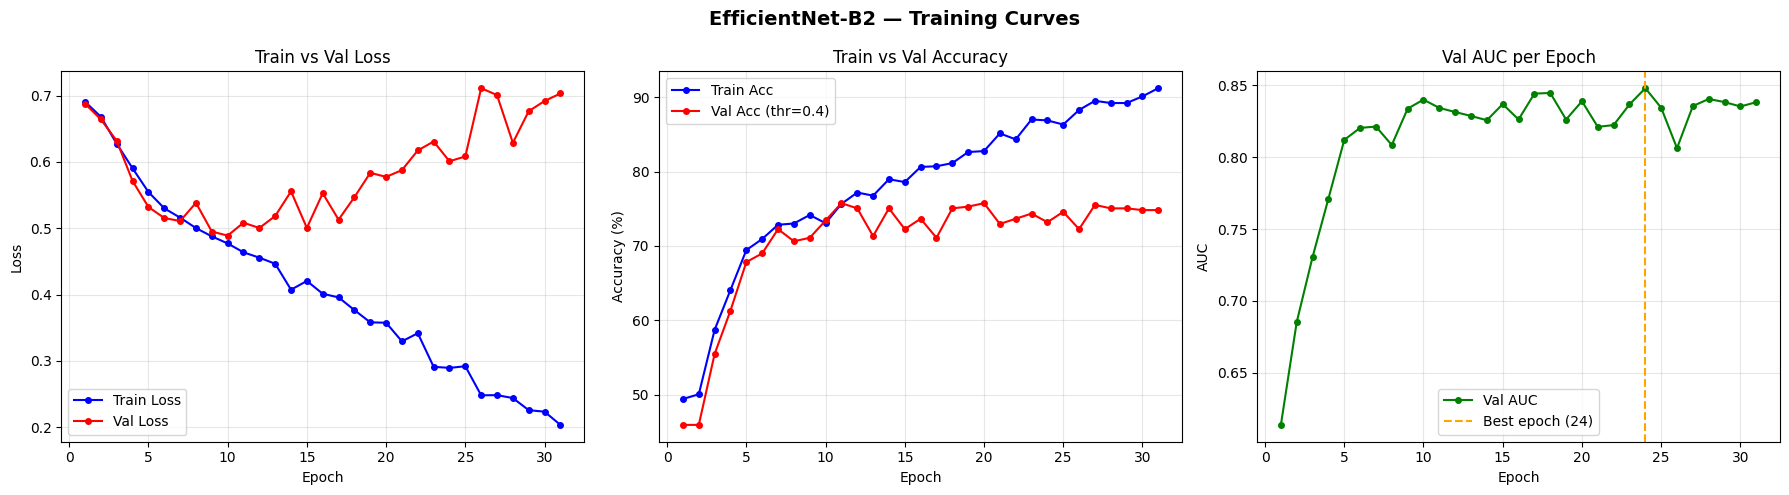

In [65]:
# ======================
# 10. VISUALISASI — Training Curves
# ======================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('EfficientNet-B2 — Training Curves', fontsize=14, fontweight='bold')
epochs_ran = range(1, len(history['train_loss']) + 1)

axes1[0].plot(epochs_ran, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes1[0].plot(epochs_ran, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes1[0].set_title('Train vs Val Loss')
axes1[0].set_xlabel('Epoch')
axes1[0].set_ylabel('Loss')
axes1[0].legend()
axes1[0].grid(alpha=0.3)

axes1[1].plot(epochs_ran, [x*100 for x in history['train_acc']], 'b-o', markersize=4, label='Train Acc')
axes1[1].plot(epochs_ran, [x*100 for x in history['val_acc']],   'r-o', markersize=4, label=f'Val Acc (thr={0.4})')
axes1[1].set_title('Train vs Val Accuracy')
axes1[1].set_xlabel('Epoch')
axes1[1].set_ylabel('Accuracy (%)')
axes1[1].legend()
axes1[1].grid(alpha=0.3)

axes1[2].plot(epochs_ran, history['val_auc'], 'g-o', markersize=4, label='Val AUC')
best_epoch = history['val_auc'].index(max(history['val_auc'])) + 1
axes1[2].axvline(x=best_epoch, color='orange', linestyle='--', linewidth=1.5,
                 label=f'Best epoch ({best_epoch})')
axes1[2].set_title('Val AUC per Epoch')
axes1[2].set_xlabel('Epoch')
axes1[2].set_ylabel('AUC')
axes1[2].legend()
axes1[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnet_b2_training_curves.png', dpi=150, bbox_inches='tight')
print("\n📈 Training curves disimpan ke efficientnet_b2_training_curves.png")

print("\nMenampilkan semua hasil visualisasi...")
plt.show()

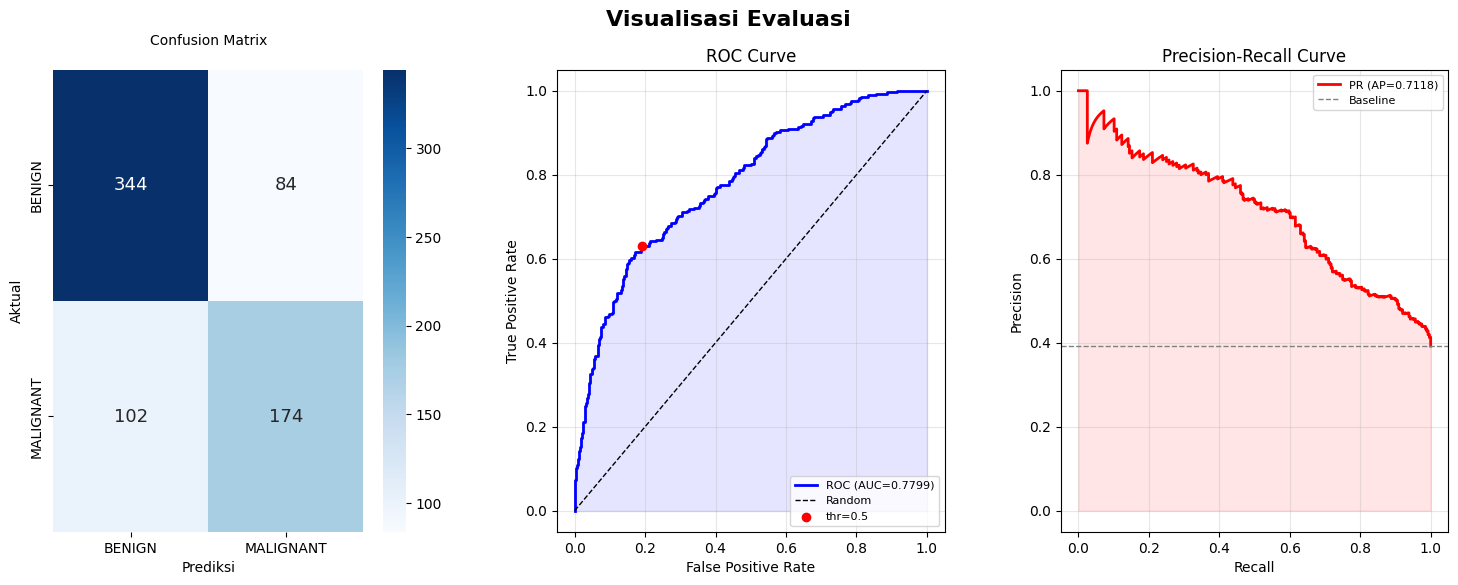

In [70]:
# ======================
# 11. VISUALISASI — Evaluasi Test Set
# ======================
fig2 = plt.figure(figsize=(18, 6))
fig2.suptitle(
    'Visualisasi Evaluasi',
    fontsize=16, fontweight='bold'
)
gs = gridspec.GridSpec(1, 3, figure=fig2, wspace=0.3)

ax_cm1 = fig2.add_subplot(gs[0, 0])
cm1 = confusion_matrix(all_labels, all_preds_05)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            ax=ax_cm1, annot_kws={'size': 13})
ax_cm1.set_title('Confusion Matrix\n', fontsize=10)
ax_cm1.set_ylabel('Aktual')
ax_cm1.set_xlabel('Prediksi')

ax_roc = fig2.add_subplot(gs[0, 1])
fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
ax_roc.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={test_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax_roc.fill_between(fpr, tpr, alpha=0.1, color='blue')
idx_th = np.argmin(np.abs(roc_thresholds - 0.5))
ax_roc.scatter(fpr[idx_th], tpr[idx_th], color='red', zorder=5, label=f'thr={0.5}')
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(alpha=0.3)

# --- 3. Precision-Recall Curve ---
ax_pr = fig2.add_subplot(gs[0, 2])
prec_vals, rec_vals, _ = precision_recall_curve(all_labels, all_probs)
avg_prec = average_precision_score(all_labels, all_probs)
ax_pr.plot(rec_vals, prec_vals, 'r-', linewidth=2, label=f'PR (AP={avg_prec:.4f})')
ax_pr.axhline(y=sum(all_labels)/len(all_labels), color='gray',
              linestyle='--', linewidth=1, label='Baseline')
ax_pr.fill_between(rec_vals, prec_vals, alpha=0.1, color='red')
ax_pr.set_title('Precision-Recall Curve')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(alpha=0.3)

plt.savefig('efficientnet_b2_evaluation.png', dpi=150, bbox_inches='tight')


🔬 Membuat visualisasi Grad-CAM...
   ✅ Grad-CAM disimpan ke gradcam_outputs/gradcam_grid.png

Menampilkan semua hasil visualisasi...


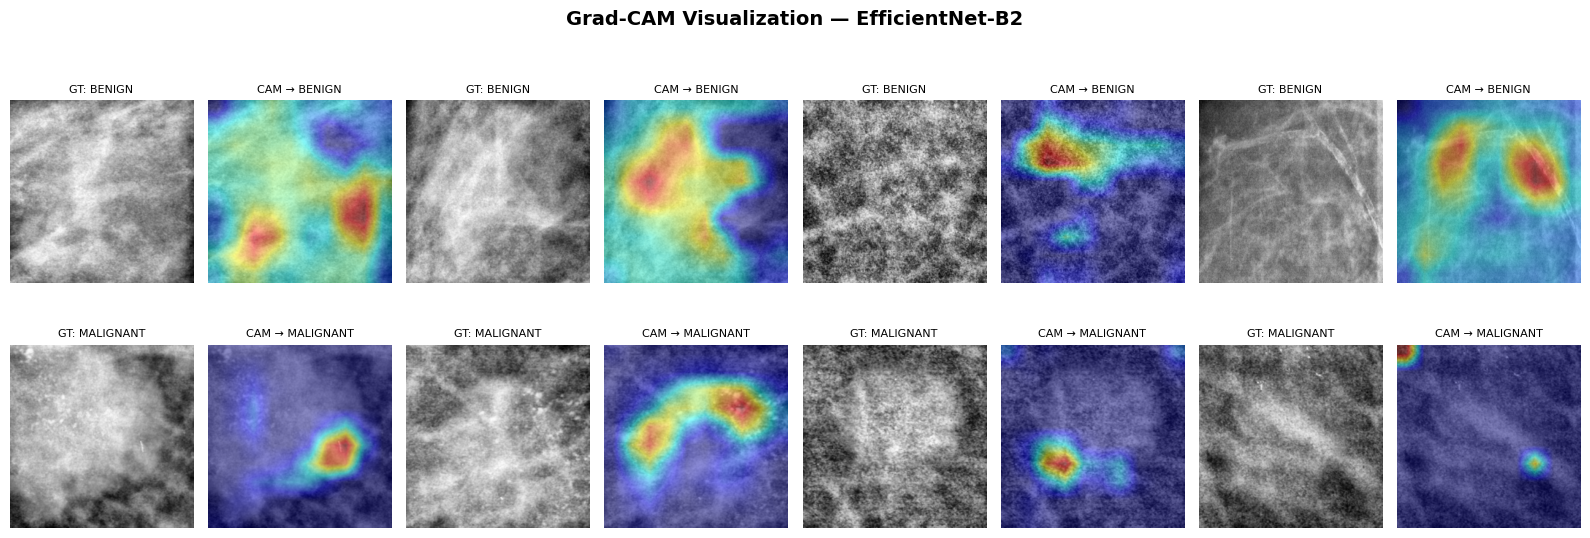

In [72]:
# ======================
# 12. GRAD-CAM
# ======================
save_gradcam_grid(
    model       = model,
    dataset     = test_dataset,
    class_names = train_dataset.classes,
    n_per_class = 4
)


print("\nMenampilkan semua hasil visualisasi...")
plt.show()

In [74]:
torch.save(model.state_dict(),
           os.path.join(CHECKPOINT_DIR, f'effnetb2_weights.pth'))

print(f"Saved : checkpoints/effnetb2_weights.pth")

Saved : checkpoints/effnetb2_weights.pth
